In [4]:
!pip install corner

In [1]:
import numpy as np
from importlib import reload
import odlib
import MahimkarOD1
import MahimkarOD2
import MahimkarOD3
import MahimkarOD4
import MahimkarOD5
import MahimkarMonte
import matplotlib.pyplot as plt
import corner

# Overview
This notebook runs the orbital-determination workflow for several assignment stages and then analyzes the Monte Carlo results.
The Monte Carlo arrays are saved to disk so you can reload the data later without rerunning the expensive simulation.


In [ ]:
#This reloads the file and calls the main function.
reload(MahimkarOD1)
MahimkarOD1.main()

[-0.34108055  0.22800625  0.87364194]


In [ ]:
values = np.loadtxt('MahimkarOD1Input.txt')
np.cross(values[0], values[1])

array([-0.0058673 ,  0.00392219,  0.01502848])

In [ ]:
reload(MahimkarOD2)
values2 = np.loadtxt('MahimkarOD2Input.txt')
MahimkarOD2.main()


0.9651803026011425
0.9651803026011425
0.9651803026011425
0.9651803026011425
Orbital Element: a reference value:1.056800055701698 calculated value:1.0568000546792962 percent difference:9.674506879239272e-08
Orbital Element: e reference value:0.3442331092168201 calculated value:0.34423311027232795 percent difference:3.0662589377089153e-07
Orbital Element: i reference value:25.15525231148689 calculated value:25.155252311486898 percent difference:2.824629731245582e-14
Orbital Element: Capital Omega reference value:236.2379805722925 calculated value:236.23798057229254 percent difference:1.2030965284054535e-14
Orbital Element: omega reference value:255.5046145946645 calculated value:255.50461448757136 percent difference:4.1914367539781336e-08
Orbital Element: M reference value:140.4194574271806 calculated value:140.41945754528308 percent difference:8.410692756264824e-08
Julian Date: 2458313.5


In [ ]:
reload(odlib)
values = np.loadtxt('MahimkarOD3Input.txt')
print(odlib.NR(5,100))

100.66419842530709


In [ ]:
reload(MahimkarOD3)
MahimkarOD3.main()


2.466615922832624
RA:  273.0387526852429
Dec:  35.997115252387964
RA: 273.0387526852429; expected value: 273.05783; percent error: 0.006986547412726513
Dec: 35.997115252387964; expected value: 36.05675; percent error: 0.16539135560480944


In [ ]:
reload(MahimkarOD4)
MahimkarOD4.main()

0.995
0.09983333333333334
0.9976989625217999
0.4996022898185827
0.9824493924417317
-0.32427006451816287
0.9949932291666667
0.09983333333333334
0.9976947512288594
0.4996235957211586
0.9823246176524854
-0.3240042187089209


In [2]:
reload(MahimkarOD5)

MahimkarOD5.main()

[ 0.43466063 -1.62060318  0.80345555] [0.0112774  0.00586661 0.00171633]


In [3]:
reload(MahimkarMonte)

# Run the Monte Carlo simulation and compute the mean values for each orbital element.
# The results are saved to .npz files so the arrays can be reused after restarting the kernel.
def calculate_arrays():
    a_arr, e_arr, i_arr, OM_arr, om_arr, M_arr = MahimkarMonte.main()

    times = 100000

    # Compute the sample mean and other summary statistics for each orbital element.
    a_calc = np.mean(a_arr)
    print("Mean of a: " + str(a_calc))
    stdev_a = np.std(a_arr)
    percent_error_a = (abs((a_calc-1.914529422994113))/(1.914529422994113))*100
    print("Percent error of a: "+ str(percent_error_a))
    print("Standard deviation of a: " + str(stdev_a))
    sdom_a = stdev_a/((times)**0.5)
    print("Standard deviation of the mean for a: " + str(sdom_a))

    e_calc = np.mean(e_arr)
    print("Mean of e: " + str(e_calc))
    stdev_e = np.std(e_arr)
    percent_error_e = (abs((e_calc-0.1417536798880002))/(0.1417536798880002))*100
    print("Percent error of e: "+ str(percent_error_e))
    print("Standard deviation of e: " + str(stdev_e))
    sdom_e = stdev_e/((times)**0.5)
    print("Standard deviation of the mean for e: " + str(sdom_e))

    i_calc = np.mean(i_arr)
    print("Mean of i: " + str(i_calc))
    stdev_i = np.std(i_arr)
    percent_error_i = (abs((i_calc-28.10839246438915))/(28.10839246438915))*100
    print("Percent error of i: "+ str(percent_error_i))
    print("Standard deviation of i: " + str(stdev_i))
    sdom_i = stdev_i/((times)**0.5)
    print("Standard deviation of the mean for i: " + str(sdom_i))

    OM_calc = np.mean(OM_arr)
    print("Mean of OM: " + str(OM_calc))
    stdev_OM = np.std(OM_arr)
    percent_error_OM = (abs((OM_calc-221.6940522631989))/(221.6940522631989))*100
    print("Percent error of OM: "+ str(percent_error_OM))
    print("Standard deviation of OM: " + str(stdev_OM))
    sdom_OM = stdev_OM/((times)**0.5)
    print("Standard deviation of the mean for OM: " + str(sdom_OM))

    om_calc = np.mean(om_arr)
    print("Mean of om: " + str(om_calc))
    stdev_om = np.std(om_arr)
    percent_error_om = (abs((om_calc-151.5689338381677))/(151.5689338381677))*100
    print("Percent error of om: "+ str(percent_error_om))
    print("Standard deviation of om: " + str(stdev_om))
    sdom_om = stdev_om/((times)**0.5)
    print("Standard deviation of the mean for OM: " + str(sdom_OM))

    M_calc = np.mean(M_arr)
    print("Mean of M: " + str(M_calc))
    stdev_M = np.std(M_arr)
    percent_error_M = (abs((M_calc-279.8603654804946))/(279.8603654804946))*100
    print("Percent error of M: "+ str(percent_error_M))
    print("Standard deviation of M: " + str(stdev_M))
    sdom_M = stdev_M/((times)**0.5)
    print("Standard deviation of the mean for M: " + str(sdom_M))

    return (a_arr, e_arr, i_arr, OM_arr, om_arr, M_arr, a_calc, e_calc, i_calc, OM_calc, om_calc, M_calc)

# Run the calculation and save the outputs for future notebook sessions.
a_arr, e_arr, i_arr, OM_arr, om_arr, M_arr, a_calc, e_calc, i_calc, OM_calc, om_calc, M_calc = calculate_arrays()
np.savez('MahimkarMonteArrays.npz', a_arr=a_arr, e_arr=e_arr, i_arr=i_arr, OM_arr=OM_arr, om_arr=om_arr, M_arr=M_arr)
np.savez('MahimkarMonteMeans.npz', a_calc=a_calc, e_calc=e_calc, i_calc=i_calc, OM_calc=OM_calc, om_calc=om_calc, M_calc=M_calc)


Mean of a: 1.9238290315943913
Percent error of a: 0.48573860963362886
Standard deviation of a: 0.007105663958072086
Standard deviation of the mean for a: 2.247008239527498e-05
Mean of e: 0.139118460106577
Percent error of e: 1.8590133134499853
Standard deviation of e: 0.0032449085335463797
Standard deviation of the mean for e: 1.0261301764923453e-05
Mean of i: 28.258571759419564
Percent error of i: 0.5342863175853121
Standard deviation of i: 0.12133791521088631
Standard deviation of the mean for i: 0.0003837041786027907
Mean of OM: 222.0313573250201
Percent error of OM: 0.15214889997173117
Standard deviation of OM: 0.2429538974583283
Standard deviation of the mean for OM: 0.0007682876823833106
Mean of om: 149.9759823296965
Percent error of om: 1.0509749380252413
Standard deviation of om: 0.9763316361499266
Standard deviation of the mean for OM: 0.0007682876823833106
Mean of M: 291.47945766401085
Percent error of M: 4.1517462337217195
Standard deviation of M: 0.5182695995821465
Standard

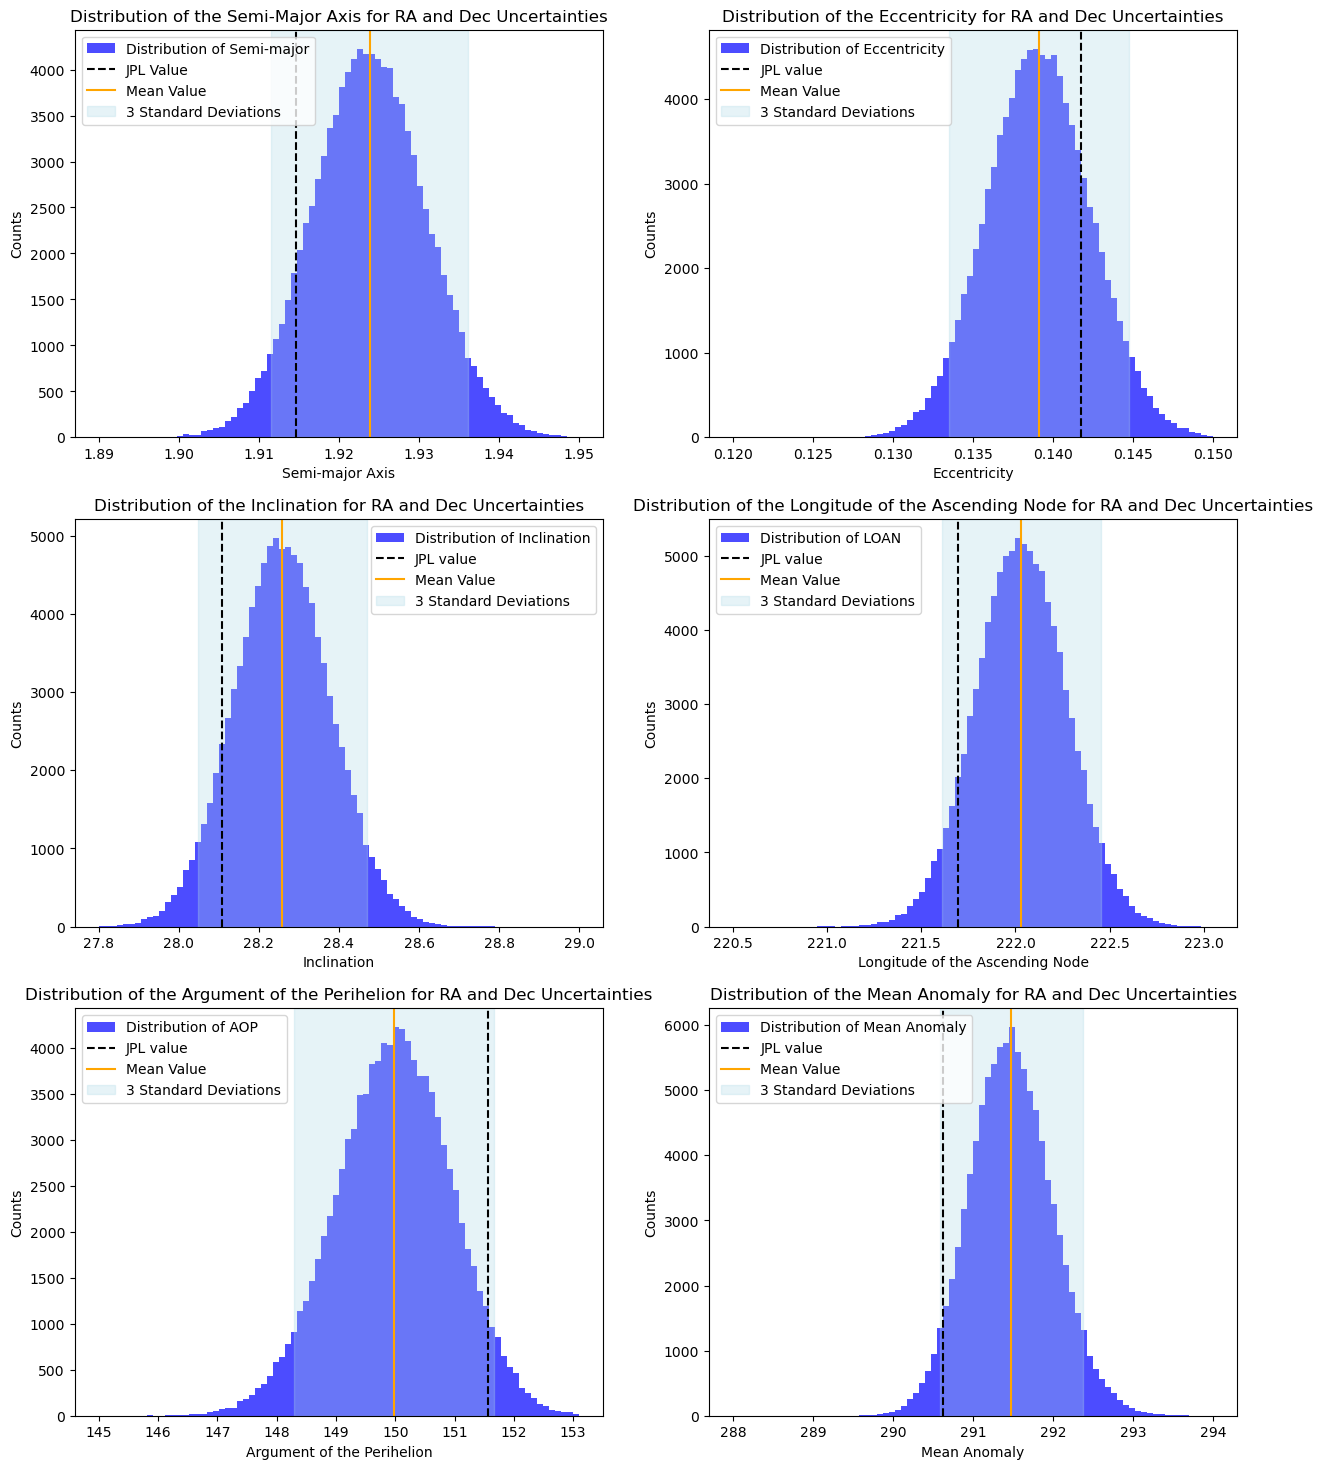

In [ ]:
reload(MahimkarMonte)

# Load the saved Monte Carlo arrays and summary statistics so the plots can be recreated
# without rerunning the expensive simulation.
def edit_graphs():
    data_arr = np.load('MahimkarMonteArrays.npz')
    a_arr = data_arr['a_arr']
    e_arr = data_arr['e_arr']
    i_arr = data_arr['i_arr']
    OM_arr = data_arr['OM_arr']
    om_arr = data_arr['om_arr']
    M_arr = data_arr['M_arr']

    data_mean = np.load('MahimkarMonteMeans.npz')
    a_calc = data_mean['a_calc']
    e_calc = data_mean['e_calc']
    i_calc = data_mean['i_calc']
    OM_calc = data_mean['OM_calc']
    om_calc = data_mean['om_calc']
    M_calc = data_mean['M_calc']

    # Create a 3x2 grid of histograms for the orbital-element distributions.
    fig, axes = plt.subplots(3, 2, figsize=(15,18))
    axes = axes.flatten()

    bin_count = 80

    # Semi-major axis histogram
    ax = axes[0]
    bins = np.linspace(1.89, 1.95, bin_count+1)
    jennifer_a = 1.914634323800664

    ax.hist(a_arr, bins, color='blue', alpha=.70, label='Distribution of Semi-major')
    ax.axvline(jennifer_a, color='black', linestyle='dashed', label='JPL Value')
    ax.axvline(a_calc, color='orange', label='Mean Value')
    ax.axvspan((a_calc-(3*0.0041108277672099475)), (a_calc+(3*0.0041108277672099475)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Semi-major Axis')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Semi-Major Axis for RA and Dec Uncertainties')

    # Eccentricity histogram
    ax = axes[1]
    bins = np.linspace(0.12, 0.15, bin_count+1)
    jennifer_e = .1417536798880002

    ax.hist(e_arr, bins, color='blue', alpha=0.7, label='Distribution of Eccentricity')
    ax.axvline(jennifer_e, color='black', linestyle='dashed', label='JPL value')
    ax.axvline(e_calc, color='orange', label='Mean Value')
    ax.axvspan((e_calc-(3*0.0018751998611254794)), (e_calc+(3*0.0018751998611254794)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Eccentricity')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Eccentricity for RA and Dec Uncertainties')

    # Inclination histogram
    ax = axes[2]
    bins = np.linspace(27.8, 29, bin_count+1)
    jennifer_i = 28.10839246438915

    ax.hist(i_arr, bins, color='blue', alpha=0.7, label='Distribution of Inclination')
    ax.axvline(jennifer_i, color='black', linestyle='dashed', label='JPL value')
    ax.axvline(i_calc, color='orange', label='Mean Value')
    ax.axvspan((i_calc-(3*0.07020706197253593)), (i_calc+(3*0.07020706197253593)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Inclination')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Inclination for RA and Dec Uncertainties')

    # Longitude of ascending node histogram
    ax = axes[3]
    bins = np.linspace(220.5, 223.05, bin_count+1)
    jennifer_OM = 221.6940522631989

    ax.hist(OM_arr, bins, color='blue', alpha=0.7, label='Distribution of LOAN')
    ax.axvline(jennifer_OM, color='black', linestyle='dashed', label='JPL value')
    ax.axvline(OM_calc, color='orange', label='Mean Value')
    ax.axvspan((OM_calc-(3*0.14048764991535423)), (OM_calc+(3*0.14048764991535423)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Longitude of the Ascending Node')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Longitude of the Ascending Node for RA and Dec Uncertainties')

    # Argument of perihelion histogram
    ax = axes[4]
    bins = np.linspace(145, 153.1, bin_count+1)
    jennifer_om = 151.5689338381677

    ax.hist(om_arr, bins, color='blue', alpha=0.7, label='Distribution of AOP')
    ax.axvline(jennifer_om, color='black', linestyle='dashed', label='JPL value')
    ax.axvline(om_calc, color='orange', label='Mean Value')
    ax.axvspan((om_calc-(3*0.5633566067353287)), (om_calc+(3*0.5633566067353287)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Argument of the Perihelion')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Argument of the Perihelion for RA and Dec Uncertainties')

    # Mean anomaly histogram
    ax = axes[5]
    bins = np.linspace(288, 294, bin_count+1)
    jennifer_M = 2.906295876316643E+02

    ax.hist(M_arr, bins, color='blue', alpha=0.7, label='Distribution of Mean Anomaly')
    ax.axvline(jennifer_M, color='black', linestyle='dashed', label='JPL value')
    ax.axvline(M_calc, color='orange', label='Mean Value')
    ax.axvspan((M_calc-(3*0.29878608931697775)), (M_calc+(3*0.29878608931697775)), color='#ADD8E6', alpha=0.3, label='3 Standard Deviations')
    ax.legend()
    ax.set_xlabel('Mean Anomaly')
    ax.set_ylabel('Counts')
    ax.set_title('Distribution of the Mean Anomaly for RA and Dec Uncertainties')

    plt.show()

edit_graphs()


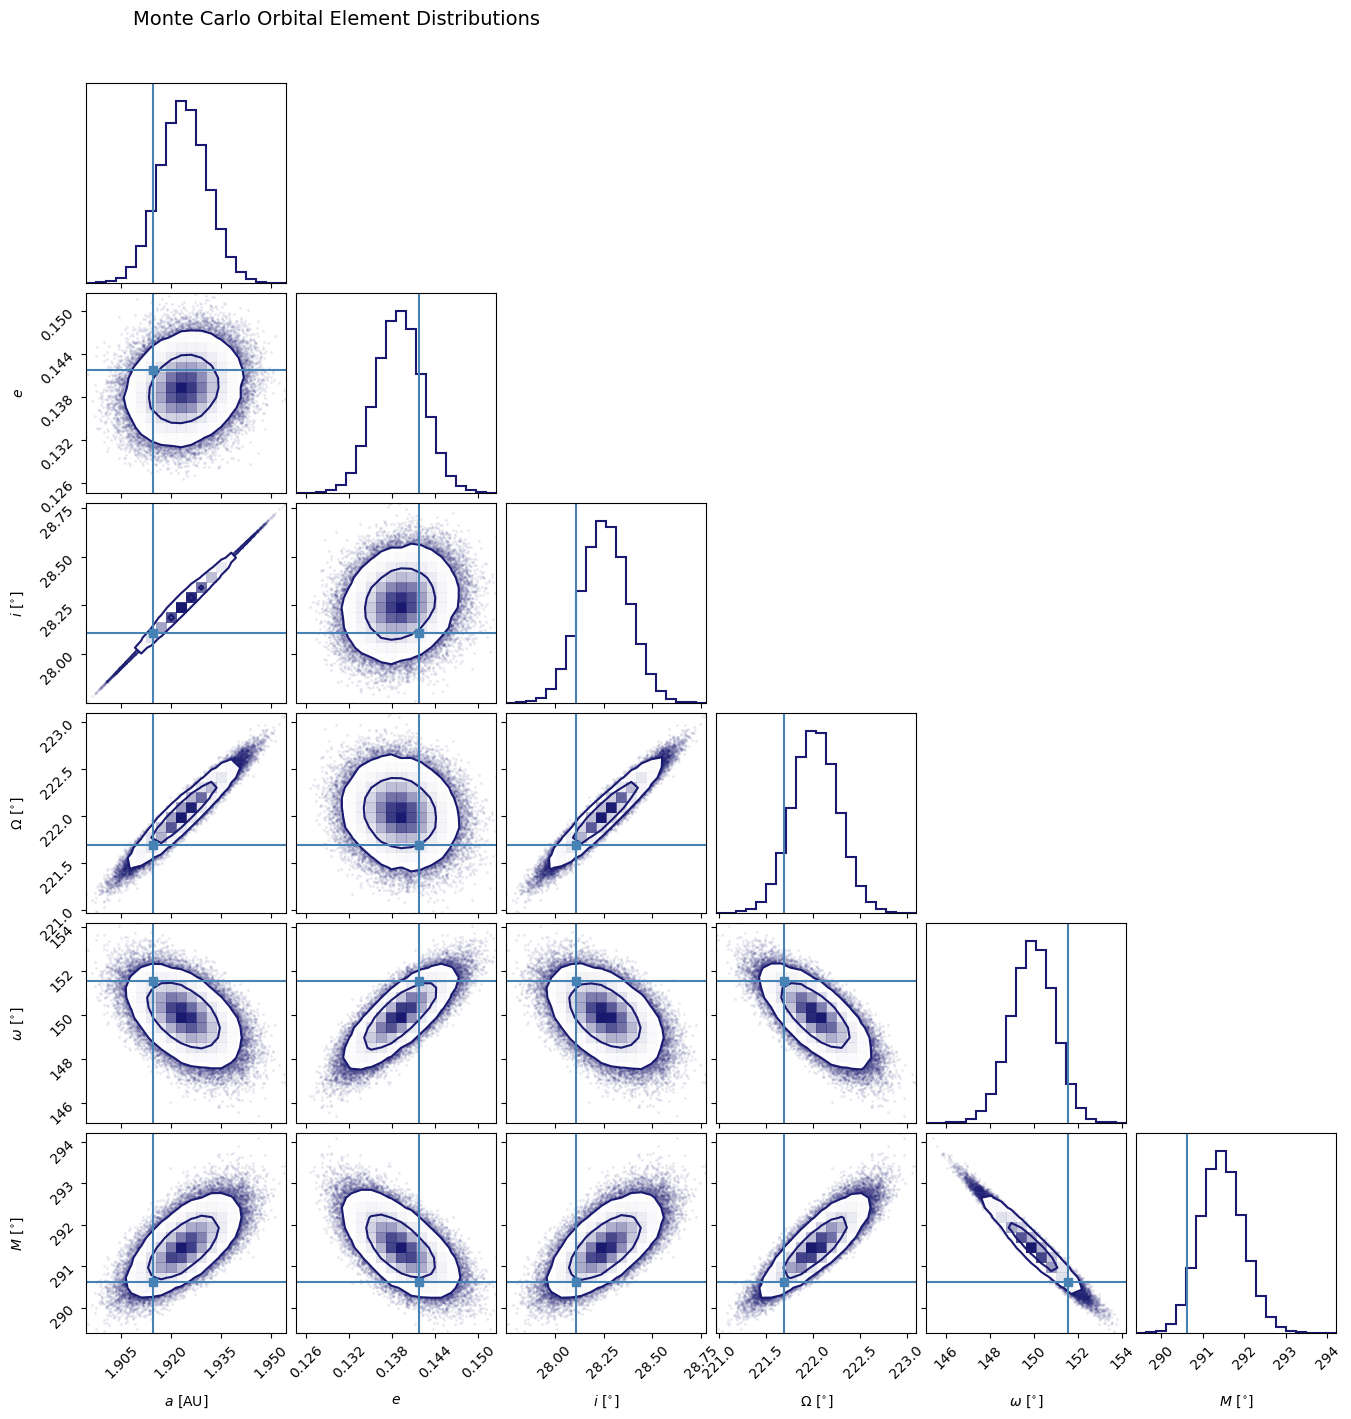

In [31]:
# Build the corner plot using the saved Monte Carlo samples.
# Each column represents one orbital element, and the diagonal plots show their individual distributions.
samples = np.vstack([a_arr, e_arr, i_arr, OM_arr, om_arr, M_arr]).T

truths = np.array([1.914634323800664, .1417536798880002, 28.10839246438915, 221.6940522631989, 151.5689338381677, 2.906295876316643E+02])

labels = [
    r"$a \ [\mathrm{AU}]$", 
    r"$e$", 
    r"$i \ [^{\circ}]$", 
    r"$\Omega \ [^{\circ}]$", 
    r"$\omega \ [^{\circ}]$", 
    r"$M \ [^{\circ}]$"
]

fig = corner.corner(
    samples,
    labels=labels,
    truths=truths,
    show_set_titles=True,
    set_title_fmt=".3f",
    set_title_kwargs={"fontsize": 10},
    levels=[0.68, 0.95],
    color="midnightblue",
    hist_kwargs={"linewidth": 1.5}
)

plt.title("Monte Carlo Orbital Element Distributions", fontsize=14, x=-4, y=6.5)
plt.savefig("monte_carlo_orbit_corner.png", dpi=300, bbox_inches="tight")
plt.show()


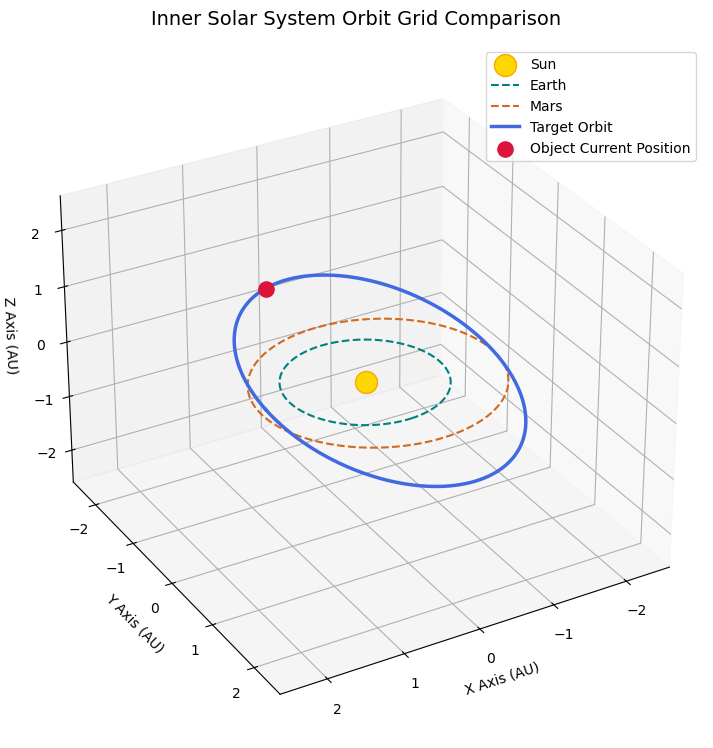

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def get_orbit_xyz(a, ec, inc_deg, om_deg, w_deg):
    #Calculates 3D heliocentric ecliptic coordinates for a full Keplerian orbit
    inc = np.radians(inc_deg)
    om  = np.radians(om_deg)
    w   = np.radians(w_deg)
    
    ta = np.linspace(0, 2 * np.pi, 600)
    r = (a * (1 - ec**2)) / (1 + ec * np.cos(ta))
    
    x_p = r * np.cos(ta)
    y_p = r * np.sin(ta)
    
    # Perifocal to Ecliptic transformation matrix elements
    cos_om, sin_om = np.cos(om), np.sin(om)
    cos_inc, sin_inc = np.cos(inc), np.sin(inc)
    cos_w, sin_w = np.cos(w), np.sin(w)

    r11 = cos_om * cos_w - sin_om * sin_w * cos_inc
    r12 = -cos_om * sin_w - sin_om * cos_w * cos_inc
    r21 = sin_om * cos_w + cos_om * sin_w * cos_inc
    r22 = -sin_om * sin_w + cos_om * cos_w * cos_inc
    r31 = sin_w * sin_inc
    r32 = cos_w * sin_inc

    x = r11 * x_p + r12 * y_p
    y = r21 * x_p + r22 * y_p
    z = r31 * x_p + r32 * y_p
    return x, y, z

#Compute Orbit Coordinates (Values in AU)
# Your Provided Object
x_obj, y_obj, z_obj = get_orbit_xyz(1.924 , 0.139 , 28.260 , 222.03, 150.01)

# Earth (Standard J2000 Ecliptic Elements)
x_earth, y_earth, z_earth = get_orbit_xyz(1.00000261, 0.01671123, 0.0, -11.26064, 102.93768)

# Mars (Standard J2000 Ecliptic Elements)
x_mars, y_mars, z_mars = get_orbit_xyz(1.52366231, 0.09341233, 1.85061, 49.57854, 286.5016)

#Pinpoint the Object's Current Position
ta_curr = np.radians(2.746107077334854E+02)
r_curr = (1.914634 * (1 - 0.141919**2)) / (1 + 0.141919 * np.cos(ta_curr))
xp, yp = r_curr * np.cos(ta_curr), r_curr * np.sin(ta_curr)

# Rotation coefficients specific to the object
inc_o, om_o, w_o = np.radians(28.10378), np.radians(221.6537), np.radians(151.4990)
r11 = np.cos(om_o)*np.cos(w_o) - np.sin(om_o)*np.sin(w_o)*np.cos(inc_o)
r12 = -np.cos(om_o)*np.sin(w_o) - np.sin(om_o)*np.cos(w_o)*np.cos(inc_o)
r21 = np.sin(om_o)*np.cos(w_o) + np.cos(om_o)*np.sin(w_o)*np.cos(inc_o)
r22 = -np.sin(om_o)*np.sin(w_o) + np.cos(om_o)*np.cos(w_o)*np.cos(inc_o)
r31 = np.sin(w_o)*np.sin(inc_o)
r32 = np.cos(w_o)*np.sin(inc_o)

xo_p, yo_p, zo_p = r11*xp + r12*yp, r21*xp + r22*yp, r31*xp + r32*yp

# --- 3. Render Multi-Orbit System ---
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')

# Core Sun Focus
ax.scatter(0, 0, 0, color='gold', s=250, label='Sun', edgecolor='orange', zorder=5)

# Map Tracks
ax.plot(x_earth, y_earth, z_earth, color='teal', linestyle='--', lw=1.5, label='Earth')
ax.plot(x_mars, y_mars, z_mars, color='chocolate', linestyle='--', lw=1.5, label='Mars')
ax.plot(x_obj, y_obj, z_obj, color='royalblue', lw=2.5, label='Target Orbit')

# Point Highlight

#print(xo_p, yo_p, zo_p)
ax.scatter(xo_p, yo_p, zo_p, color='crimson', s=120, label='Object Current Position', zorder=6)

# Graph Formatting
max_dim = 2.5
ax.set_xlim(-max_dim, max_dim)
ax.set_ylim(-max_dim, max_dim)
ax.set_zlim(-max_dim, max_dim)

ax.set_title('Inner Solar System Orbit Grid Comparison', fontsize=14, pad=15)
ax.set_xlabel('X Axis (AU)')
ax.set_ylabel('Y Axis (AU)')
ax.set_zlabel('Z Axis (AU)')
ax.legend(loc='upper right')
ax.grid(True)

#Use this to change the viewing angle of the 3D plot. The first number is the elevation and the second number is the azimuth.
ax.view_init(elev=30, azim = 60)
plt.show()
